# Laboratorio 03 - ejercicio de programación Regresión Polinomial

**Nombre del alumno**: Nisse Maximiliano Martinez Pardo \
**Link a github del laboratorio**: https://github.com/nmmartinezp/SIS420-Inteligencia-Artifical---NMMP/tree/master/Laboratorios/Laboratorio%2003

## Contexto del dataset

Este conjunto de datos recoge información sobre la planificación y optimización de la producción procedente de sistemas de fabricación híbridos (HMS, por sus siglas en inglés), que integran procesos de fabricación aditiva y sustractiva.

## Librerias usadas

In [11]:
import os
import numpy as np
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D
%matplotlib inline
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

## Cargar datos del csv - Manufacturing Production Data

In [12]:
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [13]:
# Cargar datos
df = pd.read_csv('/content/gdrive/MyDrive/Uni_Arch/SIS420/datasets/hybrid_manufacturing_categorical.csv')

# Seleccionamos columnas numéricas para regresión
# Usaremos Processing_Time para predecir Energy_Consumption
X = df[['Processing_Time']].values
y = df['Energy_Consumption'].values

# Eliminar filas con valores nulos si existen
mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
X = X[mask]
y = y[mask]

m = y.size

# imprimir algunos puntos de datos
print('{:>8s}{:>10s}'.format('X', 'y'))
print('-'*26)
for i in range(min(10, m)):
    print('{:8.0f}{:10.2f}'.format(X[i, 0], y[i]))

       X         y
--------------------------
      76     11.42
      79      6.61
      56     11.11
     106     12.50
      46      8.13
     100     13.83
      22     14.20
      79     13.86
      42      8.97
      27      3.66


In [5]:
# Crear características polinómicas de grado 3
pf = PolynomialFeatures(degree=3)  # puedes cambiar el grado
print(X.shape)
X_poly = pf.fit_transform(X.reshape(-1,1))
print(X_poly.shape)

# Crear instancia de LinearRegression
regresion_lineal = LinearRegression()

# Entrenar
regresion_lineal.fit(X_poly, y)

# Ver parámetros
print('theta = ' + str(regresion_lineal.coef_) + ', b = ' + str(regresion_lineal.intercept_))

(1000, 1)
(1000, 4)
theta = [ 0.00000000e+00 -4.37326656e-02  1.00349551e-03 -5.96158059e-06], b = 8.907686684673397


In [6]:
# Predecir y evaluar
prediccion_entrenamiento = regresion_lineal.predict(X_poly)

# Error Cuadrático Medio (MSE)
mse = mean_squared_error(y_true=y, y_pred=prediccion_entrenamiento)
rmse = np.sqrt(mse)

print('Error Cuadrático Medio (MSE) = ' + str(mse))
print('Raíz del Error Cuadrático Medio (RMSE) = ' + str(rmse))
print('Coeficiente de Determinación R2 = ' + str(regresion_lineal.score(X_poly, y)))

Error Cuadrático Medio (MSE) = 13.407331352090573
Raíz del Error Cuadrático Medio (RMSE) = 3.6616022929983223
Coeficiente de Determinación R2 = 0.003542953988593167


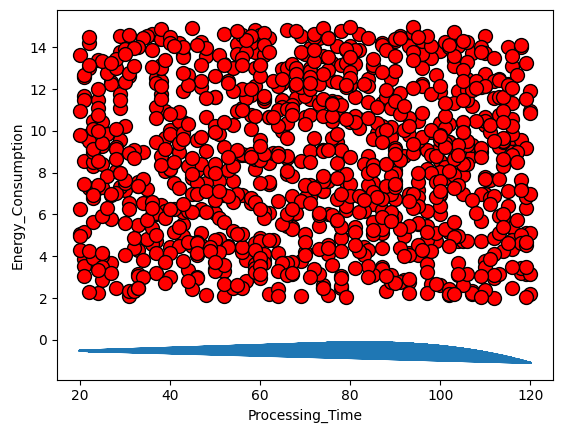

In [7]:
# Función para graficar
def plotData(x, y):
    fig = pyplot.figure()
    pyplot.plot(x, y, 'ro', ms=10, mec='k')
    pyplot.ylabel('Energy_Consumption')
    pyplot.xlabel('Processing_Time')

# Graficar datos y predicciones
plotData(X[:, 0], y)
pyplot.plot(X[:, 0], np.dot(X_poly, regresion_lineal.coef_), '-')
pyplot.show()

In [10]:
# Predecir para un nuevo valor de Processing_Time
X_new = np.array([75])  # Processing_Time = 75

pf = PolynomialFeatures(degree=3)
X_new_poly = pf.fit_transform(X_new.reshape(-1,1))

prediccion = regresion_lineal.predict(X_new_poly)
print('Predicción de Energy_Consumption para Processing_Time = 75:')
print(prediccion[0])

Predicción de Energy_Consumption para Processing_Time = 75:
8.757357188359247


## PREDICCIONES DE PRUEBA

In [18]:
# 100 PREDICCIONES

print('100 PREDICCIONES Y EFECTIVIDAD DEL MODELO')
print('='*60)

# Generar 100 valores de Processing_Time aleatorios o secuenciales
min_x = np.min(X)
max_x = np.max(X)

X_nuevos = np.random.uniform(min_x, max_x, 100).reshape(-1, 1)

# Transformar y predecir
pf = PolynomialFeatures(degree=3)
X_nuevos_poly = pf.fit_transform(X_nuevos)
predicciones = regresion_lineal.predict(X_nuevos_poly)

print('\n{:>5s} {:>12s} {:>15s}'.format('No.', 'Processing_Time', 'Energy_Consumption'))
print('-'*40)

for i in range(100):
    print('{:5d} {:12.2f} {:15.2f}'.format(i+1, X_nuevos[i, 0], predicciones[i]))

# ESTADÍSTICAS DE EFECTIVIDAD

print('\n' + '='*60)
print('ESTADÍSTICAS DE EFECTIVIDAD')
print('='*60)

# Calcular errores para todas las predicciones
errores_absolutos = np.abs(y - regresion_lineal.predict(X_poly))
errores_relativos = (errores_absolutos / y) * 100

print(f'\nTotal de predicciones realizadas: {len(predicciones)}')
print(f'Rango de Processing_Time: {min_x:.2f} - {max_x:.2f}')
print(f'\nEstadísticas de errores:')
print(f'  Error absoluto promedio: {np.mean(errores_absolutos):.2f}')
print(f'  Error absoluto máximo: {np.max(errores_absolutos):.2f}')
print(f'  Error absoluto mínimo: {np.min(errores_absolutos):.2f}')
print(f'  Error relativo promedio: {np.mean(errores_relativos):.2f}%')
print(f'  Error relativo máximo: {np.max(errores_relativos):.2f}%')
print(f'  Error relativo mínimo: {np.min(errores_relativos):.2f}%')

# Porcentaje de predicciones con cierto nivel de precisión
print(f'\nPrecisión del modelo:')
print(f'  Predicciones con error < 5%: {np.sum(errores_relativos < 5)} de {len(errores_relativos)} ({np.sum(errores_relativos < 5)/len(errores_relativos)*100:.1f}%)')
print(f'  Predicciones con error < 10%: {np.sum(errores_relativos < 10)} de {len(errores_relativos)} ({np.sum(errores_relativos < 10)/len(errores_relativos)*100:.1f}%)')
print(f'  Predicciones con error < 20%: {np.sum(errores_relativos < 20)} de {len(errores_relativos)} ({np.sum(errores_relativos < 20)/len(errores_relativos)*100:.1f}%)')

# Interpretación
print(f'\nINTERPRETACIÓN:')
if np.mean(errores_relativos) < 5:
    print('Excelente precisión: El modelo predice con muy bajo error')
elif np.mean(errores_relativos) < 10:
    print('Buena precisión: El modelo predice con error aceptable')
elif np.mean(errores_relativos) < 20:
    print('Precisión moderada: El modelo tiene margen de mejora')
else:
    print('Baja precisión: El modelo necesita mejoras o más datos')

100 PREDICCIONES Y EFECTIVIDAD DEL MODELO

  No. Processing_Time Energy_Consumption
----------------------------------------
    1        43.25            8.41
    2        49.49            8.48
    3        85.69            8.78
    4       105.48            8.46
    5       104.69            8.49
    6        94.08            8.71
    7        75.75            8.76
    8        88.44            8.77
    9        80.39            8.78
   10        87.46            8.77
   11        95.23            8.70
   12        90.46            8.75
   13        93.51            8.72
   14        41.24            8.39
   15        54.50            8.54
   16        31.22            8.34
   17        79.50            8.78
   18       116.73            7.99
   19        62.76            8.64
   20       100.61            8.59
   21        20.40            8.38
   22        86.74            8.77
   23        36.82            8.36
   24        27.89            8.34
   25       100.71            8.59
